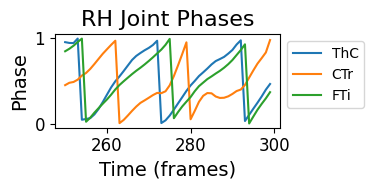

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
# from common.normalized_env_66k import CoppeliaSimEnv
# from common.normalized_env_66k_legloss import CoppeliaSimEnv
from common.normalized_env_66k_RM_error import CoppeliaSimEnv
import os
from scipy.signal import hilbert

# ======== Parameters (modify these as needed) ========= #
ENV_ID = "Medauroidea_66k_aug3c_uneven_legloss"
ALGO = "airl_logit_vx"
FILENAME = "20251022-1712" 
STEP_NUM = "950000"  
EPISODE = 1 # 
start = 250 # 
end = 300 #
fig_length = 4
fig_width = 2

STATES_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_states.csv"
ACTIONS_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_actions.csv"
VEL_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_velocities.csv"
FOOT_TRAJ_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_foot_trajs.csv"
'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
RH_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_RH_joints.csv"

os.makedirs(f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}/", exist_ok=True)
SAVE_PATH = f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}"

# ======== Read Data ======== #
states = pd.read_csv(STATES_PATH, header=None, index_col=None)
actions = pd.read_csv(ACTIONS_PATH, header=None, index_col=None)
'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
actions.columns = [
                                    'LF_ThC', 'LF_CTr', 'LF_FTi', 
                                    'LM_ThC', 'LM_CTr', 'LM_FTi', 
                                    'LH_ThC', 'LH_CTr', 'LH_FTi',
                                    'RF_ThC', 'RF_CTr', 'RF_FTi', 
                                    # 'RM_ThC', 'RM_CTr', 'RM_FTi', 
                                    'RH_ThC', 'RH_CTr', 'RH_FTi'
                                    ]
velocities = pd.read_csv(VEL_PATH, header=None, index_col=None)
foot_trajs = pd.read_csv(FOOT_TRAJ_PATH, header=None, index_col=None)

'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
rh = pd.read_csv(RH_PATH, header=None, index_col=None)
rh.columns = ['RH_ThC', 'RH_CTr', 'RH_FTi']

# ======== Denormalize Data ======== #
env = CoppeliaSimEnv(simulation = False)
states = pd.DataFrame(env.denormalize_observation(states))
actions = env.denormalize_action(actions)

'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
states.columns = [
                #   'body_x', 'body_y',
                  'body_z', 
                  'body_roll', 'body_pitch', 'body_yaw', 
                  'LF_ThC', 'LF_CTr', 'LF_FTi', 
                  'LM_ThC', 'LM_CTr', 'LM_FTi', 
                  'LH_ThC', 'LH_CTr', 'LH_FTi',
                  'RF_ThC', 'RF_CTr', 'RF_FTi', 
                  'RM_ThC', 'RM_CTr', 'RM_FTi', 
                #   'RH_ThC', 'RH_CTr', 'RH_FTi',
                  'force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH',
                #   'foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH',
                #   'contact_FL', 'contact_ML', 'contact_HL', 'contact_FR', 'contact_MR', 'contact_HR'
                  ]

'''-----------------------------------need to adjust for the leg loss-----------------------------------'''
states['RH_ThC'] = rh['RH_ThC']
states['RH_CTr'] = rh['RH_CTr']
states['RH_FTi'] = rh['RH_FTi']

forces = states[['force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH']].copy()

lf = states[['LF_ThC', 'LF_CTr', 'LF_FTi']].to_numpy()
lm = states[['LM_ThC', 'LM_CTr', 'LM_FTi']].to_numpy()
lh = states[['LH_ThC', 'LH_CTr', 'LH_FTi']].to_numpy()
rf = states[['RF_ThC', 'RF_CTr', 'RF_FTi']].to_numpy()
rm = states[['RM_ThC', 'RM_CTr', 'RM_FTi']].to_numpy()
rh = states[['RH_ThC', 'RH_CTr', 'RH_FTi']].to_numpy()

# ======== Hilbert phase ======== #
def phase(x):
    h = hilbert(x - np.mean(x))
    return (np.angle(h) + np.pi) / (2 * np.pi)

def inter_limb_plot(leg, start, end):
    phiT, phiC, phiF = map(phase, [leg[:, 0], leg[:, 1], leg[:, 2]])
    # --- Phases ---
    plt.figure(figsize=(fig_length, fig_width))
    plt.plot(np.arange(start, end), phiT[start:end], label="ThC")
    plt.plot(np.arange(start, end), phiC[start:end], label="CTr")
    plt.plot(np.arange(start, end), phiF[start:end], label="FTi")
    plt.title(f"RH Joint Phases", fontsize=16)
    plt.xlabel('Time (frames)', fontsize=14)
    plt.ylabel('Phase', fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Cyclograms (scatter instead of line) ---
    # start = 274
    # end = 300
    # for (x, y, n1, n2) in [(0, 1, "ThC", "CTr"), (1, 2, "CTr", "FTi"), (0, 2, "ThC", "FTi")]:
    #     plt.figure(figsize=(3, 3))
    #     # plt.scatter(lf[a:b, x], lf[a:b, y], s=10, alpha=0.7)
    #     plt.plot(leg[start:end,x],leg[start:end,y], marker='o', markersize=4, lw=0.7, alpha=0.8)
    #     plt.xlabel(f"{n1} (rad)")
    #     plt.ylabel(f"{n2} (rad)")
    #     plt.title(f"LF {n1}-{n2}\ncycle [{start}:{end})")
    #     plt.tight_layout()
    #     plt.savefig(f"LF_{n1}-{n2}_{start}-{end}.png", dpi=200, bbox_inches="tight")
    #     plt.show()

inter_limb_plot(rh, start, end)

In [3]:
# ======== Cyclogram per-cycle analyzer (LF) ======== #

def _contact_from_z(z, thr=0.02):
    """binary contact: 1 if z<thr else 0"""
    z = np.asarray(z)
    return (z < thr).astype(int)

def _contact_from_force(f, thr=0.27):
    """binary contact: 1 if f>thr else 0"""
    f = np.asarray(f)
    return (f > thr).astype(int)

def _touchdowns(contact):
    """0->1 indices"""
    c = np.asarray(contact).astype(int)
    td = (c[1:] == 1) & (c[:-1] == 0)
    return np.where(td)[0] + 1

def _cycles_between(ts_idx, lo, hi):
    """keep touchdown pairs fully inside [lo, hi)"""
    out = []
    for i in range(len(ts_idx)-1):
        a, b = ts_idx[i], ts_idx[i+1]
        if a >= lo and b <= hi and (b - a) > 2:
            out.append((a, b))
    return out

def _signed_area(x, y):
    """Shoelace signed area (orientation by sign)"""
    x = np.asarray(x); y = np.asarray(y)
    # close loop
    xs = np.r_[x, x[0]]
    ys = np.r_[y, y[0]]
    return 0.5 * np.sum(xs[:-1]*ys[1:] - xs[1:]*ys[:-1])

def _pc1_slope(x, y):
    """principal axis slope (PC1) and explained variance ratio"""
    XY = np.column_stack([x, y])
    XY -= XY.mean(axis=0, keepdims=True)
    C = np.cov(XY, rowvar=False)
    # eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)  # ascending
    v1 = eigvecs[:, -1]                   # PC1
    lam1 = eigvals[-1]
    lam_sum = eigvals.sum() if eigvals.sum() > 0 else 1.0
    var_ratio = float(lam1 / lam_sum)
    # slope = dy/dx = v1_y / v1_x（防 x≈0 爆炸）
    slope = float(v1[1]/v1[0]) if abs(v1[0]) > 1e-8 else np.inf
    return slope, var_ratio

def _plot_cycle_pair(x, y, name_x, name_y, t0, t1, out_dir, leg_name):
    """plot line with direction arrows (optional)"""
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(3, 3))
    plt.plot(x, y, marker='o', markersize=4, lw=0.7, alpha=0.8)
    plt.xlabel(f"{name_x} (rad)"); plt.ylabel(f"{name_y} (rad)")
    plt.title(f"{leg_name} {name_x}-{name_y}\ncycle [{t0}:{t1})")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{leg_name}_{name_x}-{name_y}_{t0}-{t1}.png"), dpi=200, bbox_inches="tight")
    plt.close(fig)

def analyze_cyclograms_for_leg(leg_angles, leg_name, foot_z, force, start, end, use_foot_trajs=True):
    """
    leg_angles: Nx3 (ThC, CTr, FTi)
    foot_z:     length-N (LF z)
    saves figures under SAVE_PATH/cyclograms_{leg_name} and CSV summary
    """
    os.makedirs(os.path.join(SAVE_PATH, f"cyclograms_{leg_name}"), exist_ok=True)
    out_dir = os.path.join(SAVE_PATH, f"cyclograms_{leg_name}")

    if use_foot_trajs:
        contact = _contact_from_z(foot_z, thr=0.02)
    else:
        contact = _contact_from_force(force, thr=0.27)
    td = _touchdowns(contact)
    cycles = _cycles_between(td, start, end)

    rows = []
    for (a, b) in cycles:
        # three pairs
        pairs = [
            (0, 1, "ThC", "CTr"),
            (1, 2, "CTr", "FTi"),
            (0, 2, "ThC", "FTi"),
        ]
        for (ix, iy, nx, ny) in pairs:
            x = leg_angles[a:b, ix]
            y = leg_angles[a:b, iy]
            if len(x) < 5 or np.allclose(x.std(), 0) or np.allclose(y.std(), 0):
                continue
            A_signed = _signed_area(x, y)
            A_abs = abs(A_signed)
            direction = "CCW" if A_signed > 0 else "CW"    # CCW: 逆时针, CW: 顺时针
            slope, pc1_ratio = _pc1_slope(x, y)

            # save fig
            _plot_cycle_pair(x, y, nx, ny, a, b, out_dir, leg_name)

            rows.append({
                "leg": leg_name, "cycle_start": a, "cycle_end": b,
                "pair": f"{nx}-{ny}",
                "area_signed": A_signed, "area_abs": A_abs,
                "direction": direction,
                "pc1_slope": slope, "pc1_var_ratio": pc1_ratio,
                "n_points": len(x)
            })

    df = pd.DataFrame(rows)
    csv_path = os.path.join(out_dir, f"cyclogram_{leg_name}_summary.csv")
    df.to_csv(csv_path, index=False)
    return df

# ==== 调用（LF；足端 z 用 foot_trajs 的第 1 列；使用你设置的 start/end）====
lf_z = foot_trajs.iloc[:, 0].to_numpy()  
lm_z = foot_trajs.iloc[:, 1].to_numpy()   
lh_z = foot_trajs.iloc[:, 2].to_numpy() 
rf_z = foot_trajs.iloc[:, 3].to_numpy()  
rm_z = foot_trajs.iloc[:, 4].to_numpy()   
rh_z = foot_trajs.iloc[:, 5].to_numpy()

lf_force = forces['force_LF'].to_numpy()
lm_force = forces['force_LM'].to_numpy()
lh_force = forces['force_LH'].to_numpy()
rf_force = forces['force_RF'].to_numpy()
rm_force = forces['force_RM'].to_numpy()
rh_force = forces['force_RH'].to_numpy()

_ = analyze_cyclograms_for_leg(lf, "LF", lf_z, lf_force, start, end, use_foot_trajs=True)
_ = analyze_cyclograms_for_leg(lm, "LM", lm_z, lm_force, start, end, use_foot_trajs=True)
_ = analyze_cyclograms_for_leg(lh, "LH", lh_z, lh_force, start, end, use_foot_trajs=True)
_ = analyze_cyclograms_for_leg(rf, "RF", rf_z, rf_force, start, end, use_foot_trajs=True)
_ = analyze_cyclograms_for_leg(rm, "RM", rm_z, rm_force, start, end, use_foot_trajs=True)
_ = analyze_cyclograms_for_leg(rh, "RH", rh_z, rh_force, start, end, use_foot_trajs=True)